# 09 - Stress testing

How do P&L and risk change when conditions get worse?
- **Costs:** ×0 (gross), ×1, ×2, ×3, plus extra slippage of 2 bp and 5 bp.
- **Volatility shock:** every move doubled.
- **Signal degradation:** 10%, 25% or 50% of signals flipped.
- **Historical:** the 10 worst BTC days in the test period.
- **Hypothetical gap:** an instant −10%, −20% or −30% move while positioned.
- **Regimes:** volatility and trend.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "scripts"))
import pandas as pd
from IPython.display import Image, display, Markdown
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 200)
import run_pipeline as rp
from src import config
T, F = config.TABLES_DIR, config.FIGURES_DIR
SYMBOL = config.SYMBOL
# False (default): display the outputs saved by scripts/run_pipeline.py.
# True re-computes the stage. Do NOT re-run 'validation' or 'test' casually:
# validation resets the experiment log and every test run adds a TEST row.
RUN_STAGE = False
def show(name, **kw):
    display(Markdown(f"**{name}**")); display(pd.read_csv(T / name, **kw))
def fig(name):
    display(Image(filename=str(F / name)))
def results(section):
    return json.loads((config.REPORTS_DIR / "results.json").read_text()).get(section, {})

In [2]:
if RUN_STAGE:
    rp.stage_stress(SYMBOL)

In [3]:
show('stress_costs.csv')

**stress_costs.csv**

,scenario,net_sharpe,annualized_return,cumulative_return,max_drawdown,daily_VaR99,worst_day
0,costs x0 (0 bp/side),0.164526,0.013528,0.037626,-0.258619,0.030463,-0.069379
1,costs x1 (7 bp/side),-5.805727,-0.601885,-0.920467,-0.921810,0.035187,-0.072009
2,costs x2 (14 bp/side),-11.395458,-0.843723,-0.993915,-0.993959,0.038687,-0.074634
3,costs x3 (21 bp/side),-16.330614,-0.938694,-0.999535,-0.999537,0.043156,-0.077254
4,base + 2 bp extra slippage,-7.456435,-0.695207,-0.961833,-0.962372,0.036250,-0.072760
5,base + 5 bp extra slippage,-9.856101,-0.795846,-0.987315,-0.987442,0.037713,-0.073885


In [4]:
show('stress_volatility.csv')

**stress_volatility.csv**

,scenario,net_sharpe,annualized_return,cumulative_return,max_drawdown,daily_VaR99,worst_day
0,base,-5.805727,-0.601885,-0.920467,-0.921810,0.035187,-0.072009
1,volatility x2,-2.845540,-0.606184,-0.922805,-0.926342,0.065017,-0.138420


In [5]:
show('stress_signal_degradation.csv')

**stress_signal_degradation.csv**

,scenario,sims,mean_net_sharpe,p5_net_sharpe,p95_net_sharpe,share_sharpe_positive
0,10% of signals flipped,200,-6.023202,-6.658927,-5.423286,0.0
1,25% of signals flipped,200,-6.309783,-7.105722,-5.532402,0.0
2,50% of signals flipped,200,-6.578064,-7.454697,-5.654526,0.0


In [6]:
show('stress_worst_btc_days.csv')

**stress_worst_btc_days.csv**

,Unnamed: 0,btc_buy_hold,strategy
0,2024-01-12 00:00:00+00:00,-0.083027,-0.007177
1,2024-03-05 00:00:00+00:00,-0.067440,0.000119
2,2024-03-19 00:00:00+00:00,-0.072354,-0.005756
3,2024-08-05 00:00:00+00:00,-0.069055,-0.072009
4,2025-03-03 00:00:00+00:00,-0.086281,-0.027894
5,2025-03-09 00:00:00+00:00,-0.067917,-0.048052
6,2025-10-10 00:00:00+00:00,-0.065645,-0.023484
7,2026-01-31 00:00:00+00:00,-0.071954,-0.013483
8,2026-02-05 00:00:00+00:00,-0.119057,-0.004675
9,2026-06-02 00:00:00+00:00,-0.070997,-0.026457


In [7]:
show('stress_gap_shock.csv')

**stress_gap_shock.csv**

,shock,loss_if_long,loss_if_short,share_time_long,share_time_short,expected_loss,loss_if_long_vs_daily_VaR99
0,-0.1,0.1,-0.1,0.091222,0.0,0.009122,2.832165
1,-0.2,0.2,-0.2,0.091222,0.0,0.018244,5.664331
2,-0.3,0.3,-0.3,0.091222,0.0,0.027367,8.496496


In [8]:
show('stress_regime_vol.csv')

**stress_regime_vol.csv**

,regime,periods,net_sharpe,mean_net_bp,hit_rate,exposure,buy_hold_mean_bp
0,high_vol,8022,-4.777994,-1.020915,0.509272,0.087385,0.663226
1,low_vol,8882,-7.751080,-1.166052,0.475896,0.091083,0.306529
2,mid_vol,7191,-5.475818,-0.915523,0.495640,0.095675,0.251417


In [9]:
show('stress_regime_trend.csv')

**stress_regime_trend.csv**

,regime,periods,net_sharpe,mean_net_bp,hit_rate,exposure,buy_hold_mean_bp
0,range,17676,-6.440513,-1.024904,0.486379,0.085144,0.278958
1,trending,6419,-4.888886,-1.092689,0.506494,0.107961,0.766486


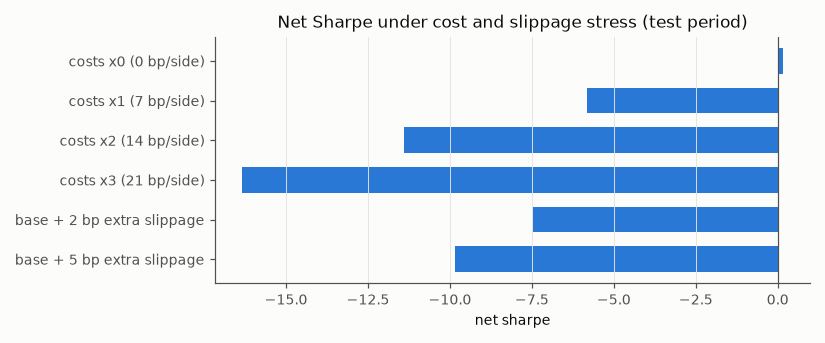

In [10]:
fig('stress_costs.png')

**Interpretation:** see the matching section of `reports/final_report.md`, written from these outputs.